# Clinical Trial Efficacy and Safety Analysis

"""
This project analyzes a synthetic clinical trial dataset
comparing Drug A with a placebo.

The analysis focuses on:
- Data quality
- Participant demographics
- Treatment efficacy
- Biomarker changes
- Treatment response
- Adverse events
- Basic statistical analysis

Note:
The dataset is entirely synthetic and contains no real
patient information.
"""

# 1. Introduction

This project performs an exploratory and statistical analysis
of a synthetic clinical trial dataset comparing Drug A with
a placebo.

The analysis evaluates participant characteristics, treatment
response, biomarker changes, and adverse events.

The dataset is synthetic and is intended solely for educational
and portfolio purposes.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
#load the raw datasets
df = pd.read_csv("../data/raw/clinical_trial_raw.csv")

In [ ]:
df.head()

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event
0,P0001,54.0,Female,Placebo,83.45,67.47,No,No
1,P0002,46.0,Female,Drug A,67.71,56.11,Yes,No
2,P0003,56.0,Male,Placebo,105.83,113.22,Yes,No
3,P0004,66.0,Female,Drug A,137.39,113.54,No,No
4,P0005,45.0,Female,Drug A,99.91,73.31,Yes,No


In [ ]:
#check the dimension
df.shape

(505, 8)

In [ ]:
df.columns


Index(['patient_id', 'age', 'sex', 'treatment_group', 'baseline_biomarker',
       'week12_biomarker', 'response', 'adverse_event'],
      dtype='str')

In [ ]:
#check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          505 non-null    str    
 1   age                 497 non-null    float64
 2   sex                 505 non-null    str    
 3   treatment_group     505 non-null    str    
 4   baseline_biomarker  505 non-null    float64
 5   week12_biomarker    497 non-null    float64
 6   response            505 non-null    str    
 7   adverse_event       505 non-null    str    
dtypes: float64(3), str(5)
memory usage: 31.7 KB


In [ ]:
# basic statistical sumary, no of unique values, most freq values, frequency
df.describe(include="object")

/tmp/ipykernel_8038/595314901.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,patient_id,sex,treatment_group,response,adverse_event
count,505,505,505,505,505
unique,500,2,2,2,2
top,P0074,Female,Placebo,Yes,No
freq,2,263,257,321,424


In [ ]:
#check missing values
df.isnull().sum()

patient_id            0
age                   8
sex                   0
treatment_group       0
baseline_biomarker    0
week12_biomarker      8
response              0
adverse_event         0
dtype: int64

In [ ]:
#calculate percentages
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary

,missing_count,missing_percentage
patient_id,0,0.00
age,8,1.58
sex,0,0.00
treatment_group,0,0.00
baseline_biomarker,0,0.00
week12_biomarker,8,1.58
response,0,0.00
adverse_event,0,0.00


In [ ]:
#check duplicates
df.duplicated().sum()

In [ ]:
df[df.duplicated()]

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event
500,P0362,NaN,Male,Placebo,138.84,137.86,No,No
501,P0074,67.0,Female,Drug A,108.69,91.80,Yes,No
502,P0375,74.0,Male,Placebo,68.17,64.14,Yes,No
503,P0156,39.0,Female,Placebo,80.55,77.45,Yes,No
504,P0105,46.0,Male,Drug A,130.20,100.84,Yes,Yes


In [14]:
#check unique values
print("Sex:")
print(df["sex"].unique())

print("\nTreatment groups:")
print(df["treatment_group"].unique())

print("\nResponse:")
print(df["response"].unique())

print("\nAdverse events:")
print(df["adverse_event"].unique())

Sex:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Treatment groups:
<StringArray>
['Placebo', 'Drug A']
Length: 2, dtype: str

Response:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Adverse events:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [15]:
#check numerical ranges
df["age"].describe()

count    497.000000
mean      48.058350
std       11.672212
min       18.000000
25%       40.000000
50%       48.000000
75%       56.000000
max       80.000000
Name: age, dtype: float64

In [16]:
#explicit check
df["age"].min(), df["age"].max()

(np.float64(18.0), np.float64(80.0))

In [17]:
#clean duplicates
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()
clean_df.duplicated().sum()

np.int64(0)

In [18]:
clean_df.shape

(500, 8)

In [19]:
#handle missing age
clean_df["age"].isnull().sum()

np.int64(7)

In [20]:
age_median = clean_df["age"].median()

print("Median age:", age_median)

Median age: 48.0


In [21]:
clean_df["age"] = clean_df["age"].fillna(age_median)

In [22]:
clean_df["age"].isnull().sum()

np.int64(0)

In [23]:
#create a biomarket_change
clean_df["biomarker_change"] = (
    clean_df["week12_biomarker"]
    - clean_df["baseline_biomarker"]
)

In [24]:
clean_df.head()

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event,biomarker_change
0,P0001,54.0,Female,Placebo,83.45,67.47,No,No,-15.98
1,P0002,46.0,Female,Drug A,67.71,56.11,Yes,No,-11.60
2,P0003,56.0,Male,Placebo,105.83,113.22,Yes,No,7.39
3,P0004,66.0,Female,Drug A,137.39,113.54,No,No,-23.85
4,P0005,45.0,Female,Drug A,99.91,73.31,Yes,No,-26.60


In [25]:
clean_df.to_csv(
    "../data/processed/clinical_trial_clean.csv",
    index=False
)

## Data Quality Summary

The raw dataset contained 505 records representing 500 unique
participants. During the quality assessment:

- 5 duplicate records were identified and removed.
- 8 missing age values were identified and replaced using
  the median age.
- 8 missing Week-12 biomarker measurements were identified.
- Week-12 biomarker values were not imputed because they are
  required to calculate individual biomarker changes.
- Categorical variables were checked for unexpected values.
- Age values were checked for values outside the expected range.

The cleaned dataset contains 500 unique participants.

In [26]:
df.shape
df.isnull().sum()
df.duplicated().sum()
clean_df.shape
clean_df.isnull().sum()
clean_df["biomarker_change"].describe()

count    492.000000
mean     -17.235874
std       12.667084
min      -55.200000
25%      -26.282500
50%      -16.545000
75%       -8.050000
max       21.100000
Name: biomarker_change, dtype: float64

# 3. Exploratory Data Analysis

The exploratory analysis compares participants receiving Drug A
with those receiving placebo.

The primary areas of interest are:

- Treatment-group distribution
- Biomarker changes from baseline to Week 12
- Treatment response
- Adverse events

The objective is to identify differences between the treatment
groups before performing formal statistical testing.

In [27]:
#no of participants
clean_df["treatment_group"].value_counts()

treatment_group
Placebo    254
Drug A     246
Name: count, dtype: int64

In [28]:
#calculate percentages
treatment_counts = clean_df["treatment_group"].value_counts()

treatment_percent = (
    clean_df["treatment_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

treatment_summary = pd.DataFrame({
    "count": treatment_counts,
    "percentage": treatment_percent
})

treatment_summary

,count,percentage
treatment_group,,
Placebo,254,50.8
Drug A,246,49.2


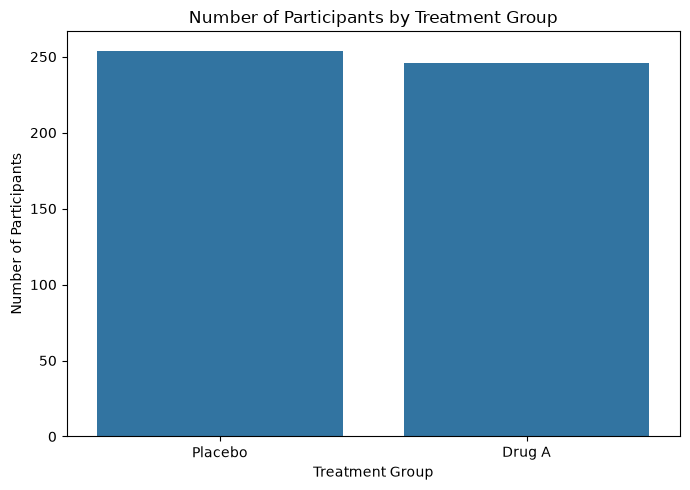

In [29]:
#first chart - treatment distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="treatment_group"
)

plt.title("Number of Participants by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

In [30]:
# age distribution by treatment
clean_df.groupby("treatment_group")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
treatment_group,,,,,,,,
Drug A,246.0,47.455285,11.831299,18.0,39.25,48.0,55.0,80.0
Placebo,254.0,48.507874,11.250206,23.0,41.00,49.0,56.0,80.0


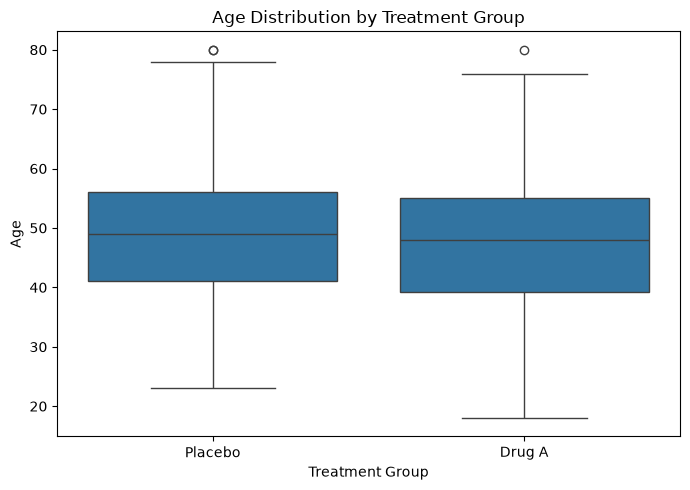

In [31]:
#create a boxplot 
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=clean_df,
    x="treatment_group",
    y="age"
)

plt.title("Age Distribution by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [32]:
clean_df["biomarker_change"]

0     -15.98
1     -11.60
2       7.39
3     -23.85
4     -26.60
       ...  
495   -34.81
496   -29.64
497   -13.52
498   -17.70
499   -27.52
Name: biomarker_change, Length: 500, dtype: float64

In [33]:
#compare groups
biomarker_summary = (
    clean_df
    .groupby("treatment_group")["biomarker_change"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(2)
)

biomarker_summary

,count,mean,median,std,min,max
treatment_group,,,,,,
Drug A,240,-25.65,-26.05,10.16,-55.20,2.6
Placebo,252,-9.22,-9.44,9.13,-32.06,21.1


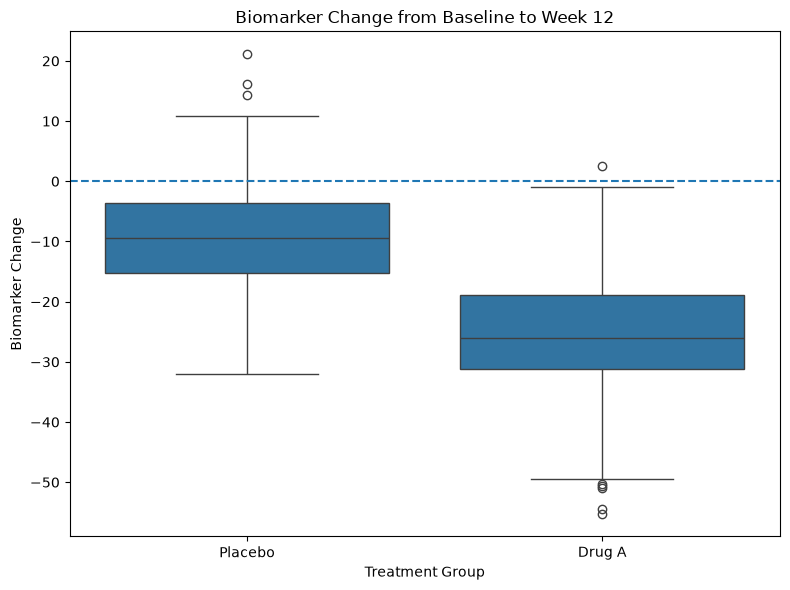

In [34]:
#visualizing biomarker changes
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=clean_df,
    x="treatment_group",
    y="biomarker_change"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Biomarker Change from Baseline to Week 12")
plt.xlabel("Treatment Group")
plt.ylabel("Biomarker Change")

plt.tight_layout()
plt.show()

In [35]:
#response rate
response_counts = pd.crosstab(
    clean_df["treatment_group"],
    clean_df["response"]
)

response_counts

response,No,Yes
treatment_group,,
Drug A,72,174
Placebo,111,143


In [36]:
response_rate = (
    pd.crosstab(
        clean_df["treatment_group"],
        clean_df["response"],
        normalize="index"
    ) * 100
).round(2)

response_rate

response,No,Yes
treatment_group,,
Drug A,29.27,70.73
Placebo,43.70,56.30


In [37]:
#creating response chart 
response_plot = (
    clean_df
    .assign(
        response_binary=(
            clean_df["response"] == "Yes"
        ).astype(int)
    )
    .groupby("treatment_group")["response_binary"]
    .mean()
    .mul(100)
    .reset_index(name="response_rate")
)

response_plot

,treatment_group,response_rate
0,Drug A,70.731707
1,Placebo,56.299213


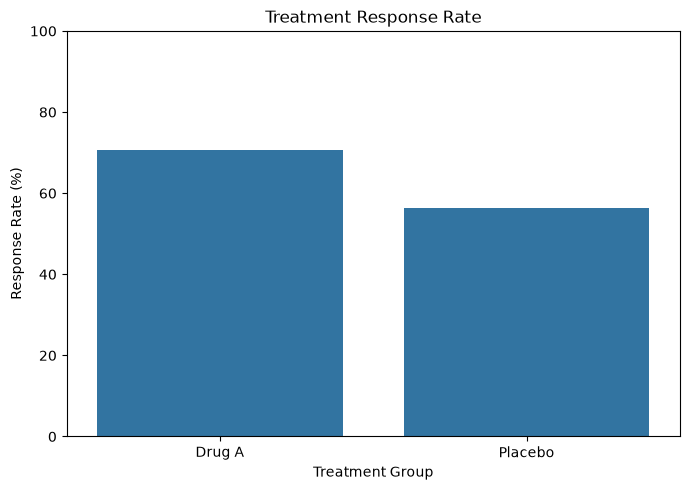

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=response_plot,
    x="treatment_group",
    y="response_rate"
)

plt.title("Treatment Response Rate")
plt.xlabel("Treatment Group")
plt.ylabel("Response Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [39]:
#adverse event - safety analysis
adverse_event_rate = (
    pd.crosstab(
        clean_df["treatment_group"],
        clean_df["adverse_event"],
        normalize="index"
    ) * 100
).round(2)

adverse_event_rate

adverse_event,No,Yes
treatment_group,,
Drug A,81.71,18.29
Placebo,86.22,13.78


In [40]:
#creating the safety chart 
ae_plot = (
    clean_df
    .assign(
        adverse_event_binary=(
            clean_df["adverse_event"] == "Yes"
        ).astype(int)
    )
    .groupby("treatment_group")["adverse_event_binary"]
    .mean()
    .mul(100)
    .reset_index(name="adverse_event_rate")
)

ae_plot

,treatment_group,adverse_event_rate
0,Drug A,18.292683
1,Placebo,13.779528


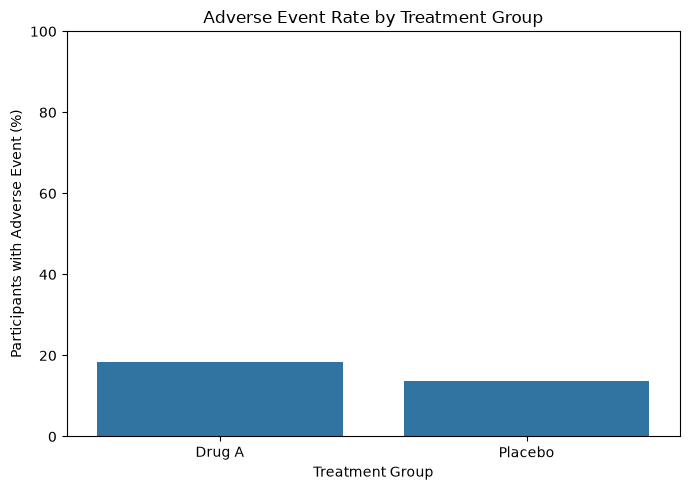

In [41]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=ae_plot,
    x="treatment_group",
    y="adverse_event_rate"
)

plt.title("Adverse Event Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Participants with Adverse Event (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [42]:
#difference in response rates
drug_a_response = response_rate.loc["Drug A", "Yes"]
placebo_response = response_rate.loc["Placebo", "Yes"]

response_difference = drug_a_response - placebo_response

print(f"Drug A response rate: {drug_a_response:.2f}%")
print(f"Placebo response rate: {placebo_response:.2f}%")
print(f"Difference: {response_difference:.2f} percentage points")

Drug A response rate: 70.73%
Placebo response rate: 56.30%
Difference: 14.43 percentage points


## Exploratory Findings

The treatment groups were reasonably balanced, with 246
participants receiving Drug A and 254 receiving placebo.

Among participants with available Week-12 biomarker measurements,
Drug A showed a greater average reduction in the biomarker
(mean change = -25.65) compared with placebo
(mean change = -9.22).

The observed difference in mean biomarker change was
approximately -16.43 units.

Drug A also had a higher response rate (70.73%) compared with
placebo (56.30%), representing a difference of approximately
14.43 percentage points.

These findings are exploratory and do not by themselves establish
statistical significance. Formal statistical testing will be
performed in the next section.

In [43]:
treatment_summary

,count,percentage
treatment_group,,
Placebo,254,50.8
Drug A,246,49.2


In [44]:
biomarker_summary

,count,mean,median,std,min,max
treatment_group,,,,,,
Drug A,240,-25.65,-26.05,10.16,-55.20,2.6
Placebo,252,-9.22,-9.44,9.13,-32.06,21.1


In [45]:
response_rate

response,No,Yes
treatment_group,,
Drug A,29.27,70.73
Placebo,43.70,56.30


In [46]:
adverse_event_rate

adverse_event,No,Yes
treatment_group,,
Drug A,81.71,18.29
Placebo,86.22,13.78


# 4. Statistical Analysis

The exploratory analysis showed differences between Drug A and
placebo in biomarker change.

A statistical hypothesis test will be performed to determine
whether the observed difference in mean biomarker change is
statistically significant.

An independent two-sample t-test will be used because the
biomarker changes are being compared between two independent
treatment groups.

In [47]:
drug_a_change = clean_df.loc[
    clean_df["treatment_group"] == "Drug A",
    "biomarker_change"
].dropna()

placebo_change = clean_df.loc[
    clean_df["treatment_group"] == "Placebo",
    "biomarker_change"
].dropna()

In [48]:
print("Drug A:", len(drug_a_change))
print("Placebo:", len(placebo_change))

Drug A: 240
Placebo: 252


In [ ]:
#welch's t-test
t_stat, p_value = stats.ttest_ind(
    drug_a_change,
    placebo_change,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -18.828333631274422
p-value: 1.3873918952192907e-59


In [50]:
mean_difference = drug_a_change.mean() - placebo_change.mean()

print("Mean difference:", mean_difference)

Mean difference: -16.42700992063492


In [51]:
#calculating confidence interval
from scipy.stats import t

n1 = len(drug_a_change)
n2 = len(placebo_change)

mean1 = drug_a_change.mean()
mean2 = placebo_change.mean()

var1 = drug_a_change.var()
var2 = placebo_change.var()

se = np.sqrt(
    (var1 / n1) +
    (var2 / n2)
)

df_welch = (
    (var1 / n1 + var2 / n2) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

critical_value = t.ppf(
    0.975,
    df_welch
)

margin_of_error = critical_value * se

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("Mean difference:", mean_difference)
print("95% CI:", ci_lower, ci_upper)

Mean difference: -16.42700992063492
95% CI: -18.14134049376265 -14.712679347507187


## Statistical Test Result

An independent two-sample Welch's t-test was used to compare
biomarker changes between Drug A and placebo.

The null hypothesis stated that there was no difference in mean
biomarker change between the two treatment groups.

The alternative hypothesis stated that a difference existed.

The resulting p-value was statistically significant at the
0.05 significance level, indicating evidence of a difference
in mean biomarker change between the treatment groups.

Drug A showed a substantially greater average reduction in the
biomarker compared with placebo.

The statistical result should be interpreted together with the
estimated effect size and confidence interval rather than using
the p-value alone.

In [52]:
final_summary = pd.DataFrame({
    "Metric": [
        "Participants",
        "Mean biomarker change",
        "Response rate (%)",
        "Adverse event rate (%)"
    ],
    "Drug A": [
        246,
        round(drug_a_change.mean(), 2),
        round(drug_a_response, 2),
        round(ae_plot.loc[
            ae_plot["treatment_group"] == "Drug A",
            "adverse_event_rate"
        ].iloc[0], 2)
    ],
    "Placebo": [
        254,
        round(placebo_change.mean(), 2),
        round(placebo_response, 2),
        round(ae_plot.loc[
            ae_plot["treatment_group"] == "Placebo",
            "adverse_event_rate"
        ].iloc[0], 2)
    ]
})

final_summary

,Metric,Drug A,Placebo
0,Participants,246.00,254.00
1,Mean biomarker change,-25.65,-9.22
2,Response rate (%),70.73,56.30
3,Adverse event rate (%),18.29,13.78


# 5. Key Findings

## Efficacy

- The study included 246 participants in the Drug A group and
  254 participants in the placebo group.
- Drug A showed a greater mean reduction in the biomarker
  compared with placebo.
- Mean biomarker change was -25.65 units for Drug A compared
  with -9.22 units for placebo.
- The observed difference in mean change was -16.43 units.
- The response rate was 70.73% for Drug A compared with 56.30%
  for placebo.

## Safety

- The observed adverse-event rate was 18.29% for Drug A and
  13.78% for placebo.
- Therefore, Drug A showed higher observed adverse-event rates
  in this synthetic dataset.

## Statistical Evidence

A Welch two-sample t-test was used to compare biomarker changes
between the treatment groups.

The estimated mean difference was -16.43 units with a 95%
confidence interval of -18.14 to -14.71.

The p-value was approximately 1.39 × 10^-59, providing strong
statistical evidence of a difference in mean biomarker change
between the two treatment groups.

## Overall Interpretation

The exploratory analysis suggests that Drug A produced a larger
biomarker reduction and higher response rate than placebo in this
synthetic dataset. However, Drug A also showed a higher observed
adverse-event rate.

These findings are for demonstration and portfolio purposes only.
The dataset is synthetic and does not represent actual clinical
trial evidence.

# 6. Limitations

- The dataset is entirely synthetic and does not contain real
  clinical trial data.
- The data-generating process is simplified and does not represent
  the complexity of real clinical studies.
- Only a small number of clinical variables were included.
- The analysis does not account for all potential confounding
  variables.
- The statistical analysis is intentionally limited to basic
  exploratory methods.
- Statistical significance should not be interpreted as clinical
  significance.
- The observed findings should not be used to make real medical
  or treatment decisions.

# 7. Conclusion

This project demonstrates an end-to-end workflow for analyzing
clinical trial-style data using Python.

The workflow included data profiling, identification of missing
values and duplicate records, data cleaning, exploratory analysis,
visualization, treatment-group comparison, and statistical testing.

The project was designed to demonstrate fundamental data-analysis
skills while providing exposure to common clinical research
concepts such as treatment groups, baseline measurements,
biomarkers, response, and adverse events.